In [ ]:
%pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.1/125.1 kB 9.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
from qiskit import QuantumCircuit

In [ ]:
circ = QuantumCircuit(3)

In [ ]:
# hadamard on first qubit
circ.h(0)

# cnot gate on second qubit with first one
circ.cx(0, 1)

# another cnot gate on third one with the first one giving us GHZ state
circ.cx(0, 2)

# measure all

In [ ]:
circ.draw("text")

┌───┐          
q_0: ┤ H ├──■────■──
     └───┘┌─┴─┐  │  
q_1: ─────┤ X ├──┼──
          └───┘┌─┴─┐
q_2: ──────────┤ X ├
               └───┘

In [ ]:
from qiskit.quantum_info import Statevector

# Set the initial state of the simulator to the ground state using from_int
state = Statevector.from_int(0, 2**3)

# Evolve the state by the quantum circuit
state = state.evolve(circ)

#draw using latex
state.draw('latex')

<IPython.core.display.Latex object>

In [ ]:
from qiskit.visualization import array_to_latex

#Alternative way of representing in latex
array_to_latex(state)

<IPython.core.display.Latex object>

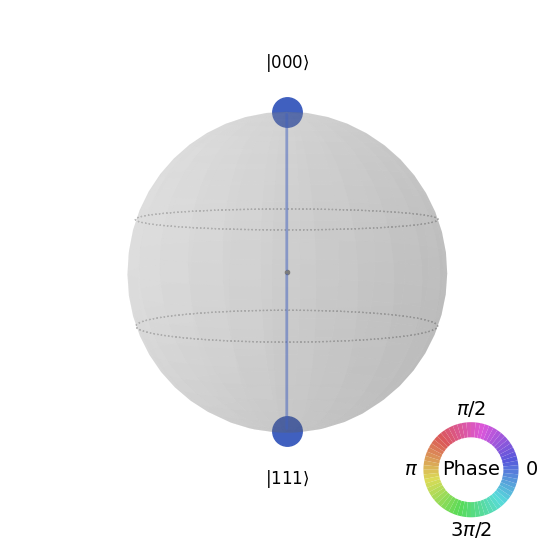

In [ ]:
state.draw('qsphere')

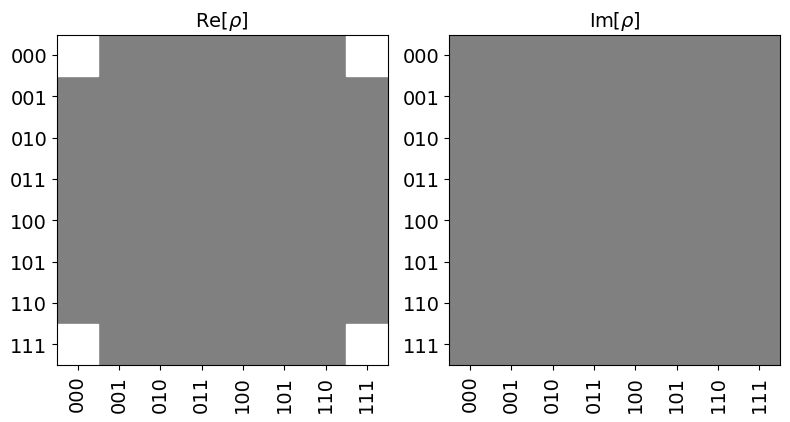

In [ ]:
state.draw('hinton')

In [ ]:
from qiskit.quantum_info import Operator

U = Operator(circ)

In [ ]:
U.data

array([[ 0.70710678+0.j,  0.70710678+0.j,  0.        +0.j,
         0.        +0.j,  0.        +0.j,  0.        +0.j,
         0.        +0.j,  0.        +0.j],
       [ 0.        +0.j,  0.        +0.j,  0.        +0.j,
         0.        +0.j,  0.        +0.j,  0.        +0.j,
         0.70710678+0.j, -0.70710678+0.j],
       [ 0.        +0.j,  0.        +0.j,  0.70710678+0.j,
         0.70710678+0.j,  0.        +0.j,  0.        +0.j,
         0.        +0.j,  0.        +0.j],
       [ 0.        +0.j,  0.        +0.j,  0.        +0.j,
         0.        +0.j,  0.70710678+0.j, -0.70710678+0.j,
         0.        +0.j,  0.        +0.j],
       [ 0.        +0.j,  0.        +0.j,  0.        +0.j,
         0.        +0.j,  0.70710678+0.j,  0.70710678+0.j,
         0.        +0.j,  0.        +0.j],
       [ 0.        +0.j,  0.        +0.j,  0.70710678+0.j,
        -0.70710678+0.j,  0.        +0.j,  0.        +0.j,
         0.        +0.j,  0.        +0.j],
       [ 0.        +0.j,  0.      

In [ ]:
U.draw('latex')

<IPython.core.display.Latex object>

In [ ]:
# quantum circuit
meas = QuantumCircuit(3, 3)
meas.barrier(range(3))

# mapping the quantum measurement to classical bit
meas.measure(range(3), range(3))

qc = meas.compose(circ, range(3), front = True)

qc.draw('text')

┌───┐           ░ ┌─┐      
q_0: ┤ H ├──■────■───░─┤M├──────
     └───┘┌─┴─┐  │   ░ └╥┘┌─┐   
q_1: ─────┤ X ├──┼───░──╫─┤M├───
          └───┘┌─┴─┐ ░  ║ └╥┘┌─┐
q_2: ──────────┤ X ├─░──╫──╫─┤M├
               └───┘ ░  ║  ║ └╥┘
c: 3/═══════════════════╩══╩══╩═
                        0  1  2

In [ ]:
%pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 81.2 MB/s eta 0:00:00


In [ ]:
from qiskit import transpile
from qiskit_aer import AerSimulator

# decide our backend for running our circuit on a simulated quantum computer
backend = AerSimulator()

# this is a compiling step where we connect our circuit with the backend simulator
qc_compiled = transpile(qc, backend)

# this is where we run the simulator
job_sim = backend.run(qc_compiled, shots = 1024)

# and store the simulator results in the results var
results = job_sim.result()

In [ ]:
counts = results.get_counts(qc_compiled)
print(counts)

{'111': 524, '000': 500}


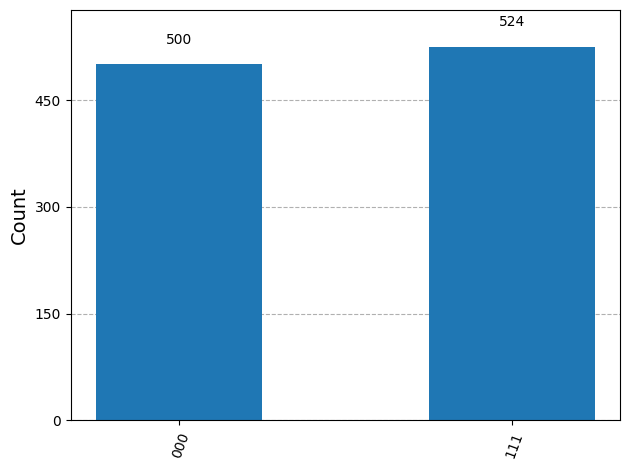

In [ ]:
from qiskit.visualization import plot_histogram

plot_histogram(counts)

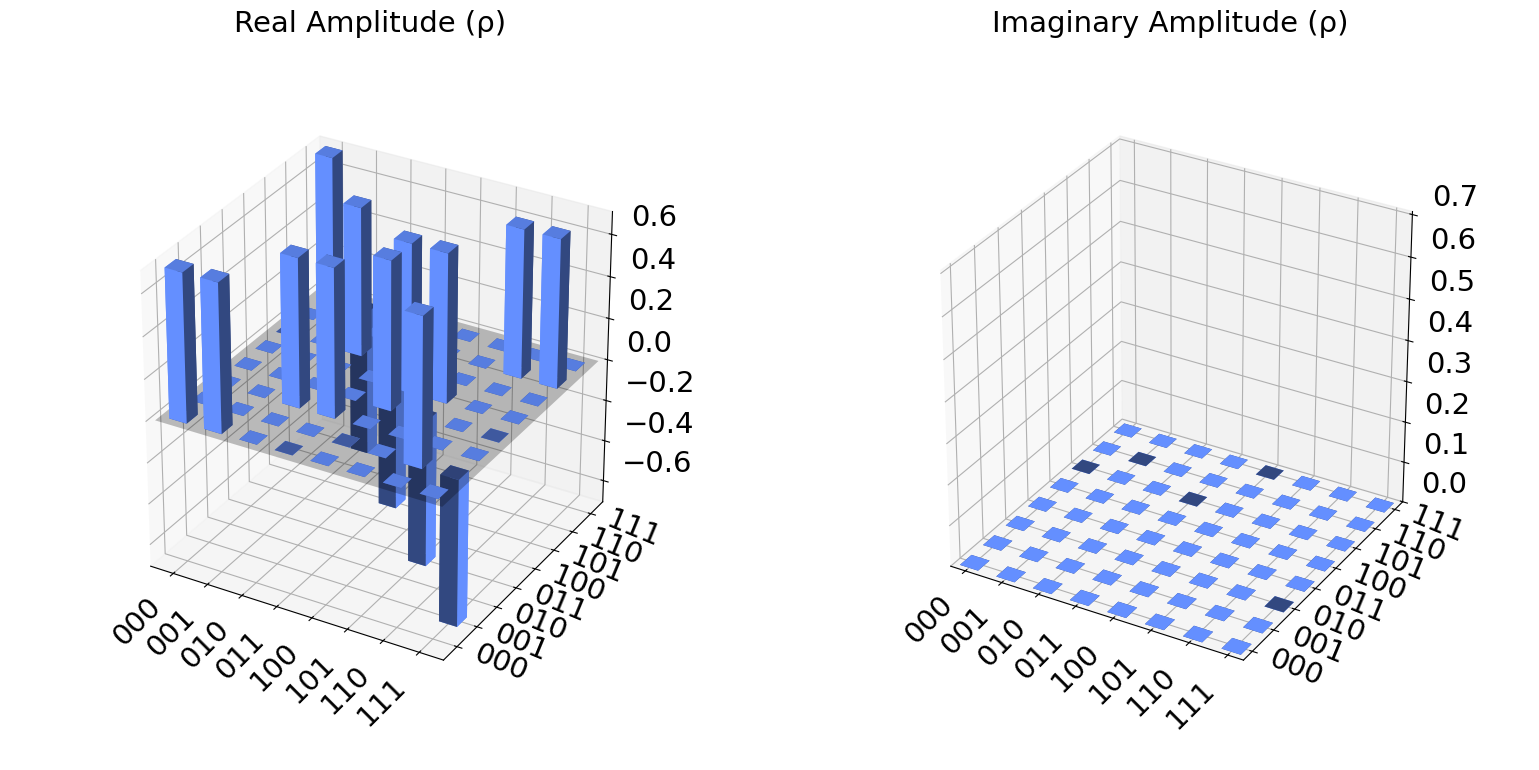

In [ ]:
from qiskit.visualization import plot_state_city
plot_state_city(U)

# New Section

In [ ]:
# import required stuff
from qiskit import *
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

In [ ]:
# defining a two bit quantum system with hadamard and cnot gate
# here (2, 2) means that 2 quantum bits are mapping on 2 classical bits as output
bell = QuantumCircuit(2, 2)
bell.h(0)
bell.cx(0, 1)

# this is the sceond part of circuit where u define the measurement in first part u define the gates
# and here u define the measurements projections and compose them afterwords in a one system
meas = QuantumCircuit(2, 2)
meas.measure([0, 1], [0, 1])
qc = meas.compose(bell, [0, 1], front = True)

# since we cannot run the quantum system on our pc we define a simulator and using transpile
# we connect them together this converts the high level qiskit into qasm which is low level quantum assembly language
backend = AerSimulator()
qc_compiled = transpile(qc, backend)

results = backend.run(qc_compiled, shots = 1024)
results = results.result()

counts = results.get_counts()
print(counts)

{'00': 516, '11': 508}


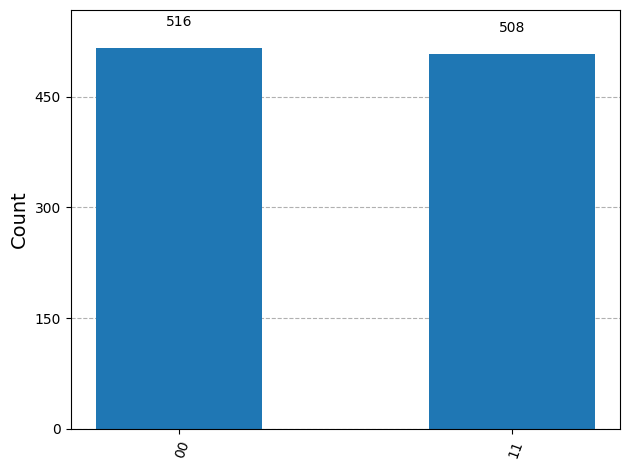

In [ ]:
plot_histogram(counts)

In [ ]:
second_result = backend.run(qc_compiled, shots = 1024)
second_result = second_result.result()

second_count = second_result.get_counts()
print(second_count)

{'00': 532, '11': 492}


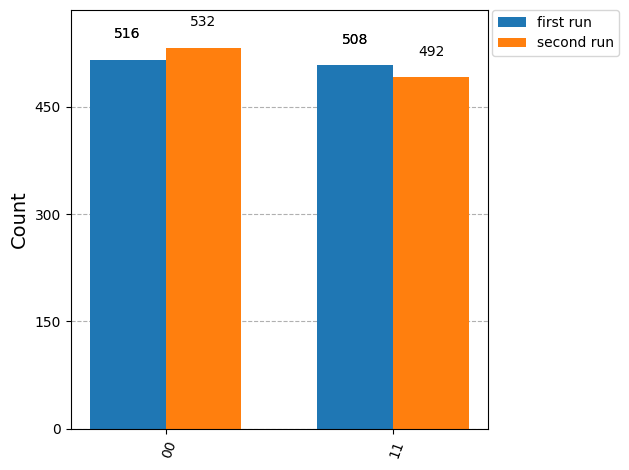

In [ ]:
legend = ["first run", "second run"]
plot_histogram([counts, second_count], legend = legend)

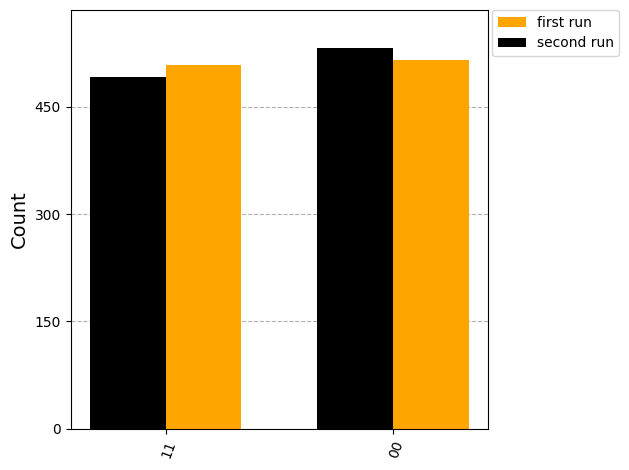

In [ ]:
plot_histogram([counts, second_count], legend=legend, sort='desc', color=['orange', 'black'], bar_labels=False)

In [ ]:
from qiskit.visualization import plot_state_city, plot_bloch_multivector
from qiskit.visualization import plot_state_paulivec, plot_state_hinton
from qiskit.visualization import plot_state_qsphere

Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))


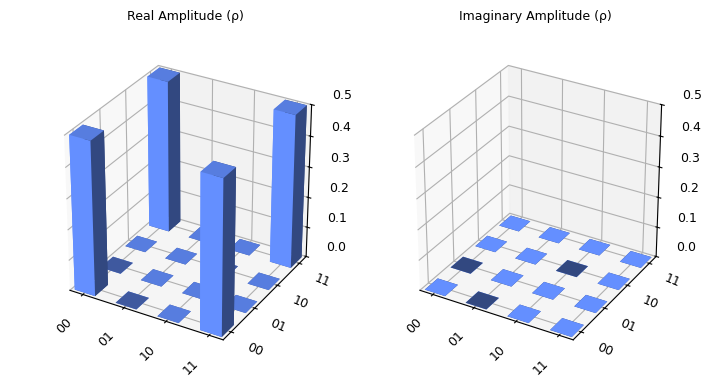

In [ ]:
from qiskit_aer.library import SaveStatevector

# used the newer version here
backend = AerSimulator(method = 'statevector')

# also made copy of my quantum circuit without measurement so it dont collapse
# and saved that to a statevector form so i can plot it later
qc_without_measurement = bell.copy()
qc_without_measurement.save_statevector()

new_qc_compiled = transpile(qc_without_measurement, backend)


result = backend.run(new_qc_compiled).result()
statevector = result.data()['statevector'] # Access data without specifying experiment

# Directly simulate the statevector
psi = Statevector.from_instruction(bell)
print(psi)

plot_state_city(statevector, figsize=(7, 4))

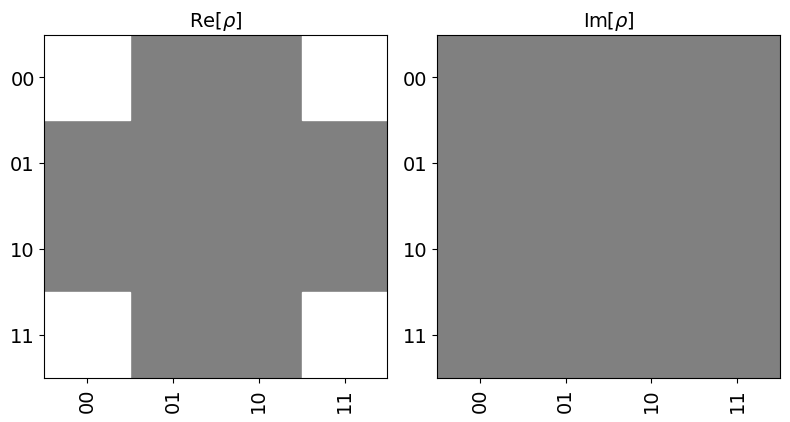

In [ ]:
plot_state_hinton(psi)

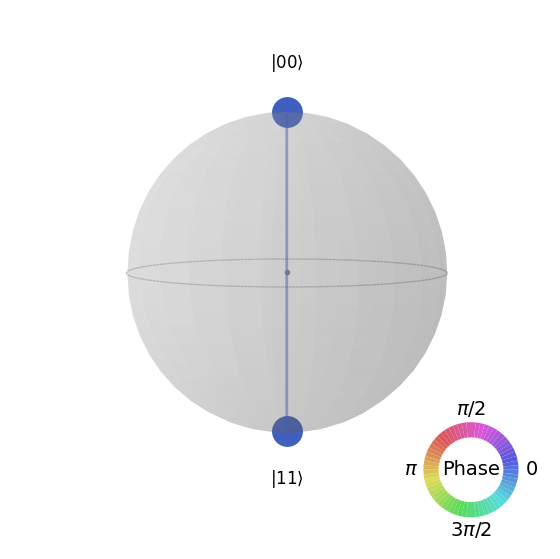

In [ ]:
plot_state_qsphere(psi)

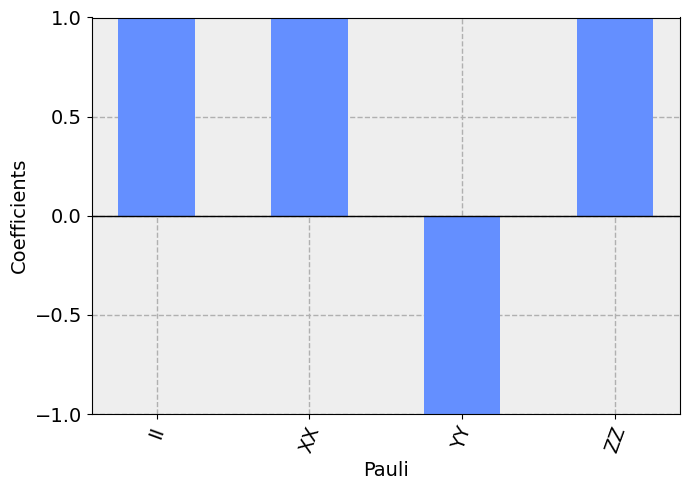

In [ ]:
plot_state_paulivec(psi)

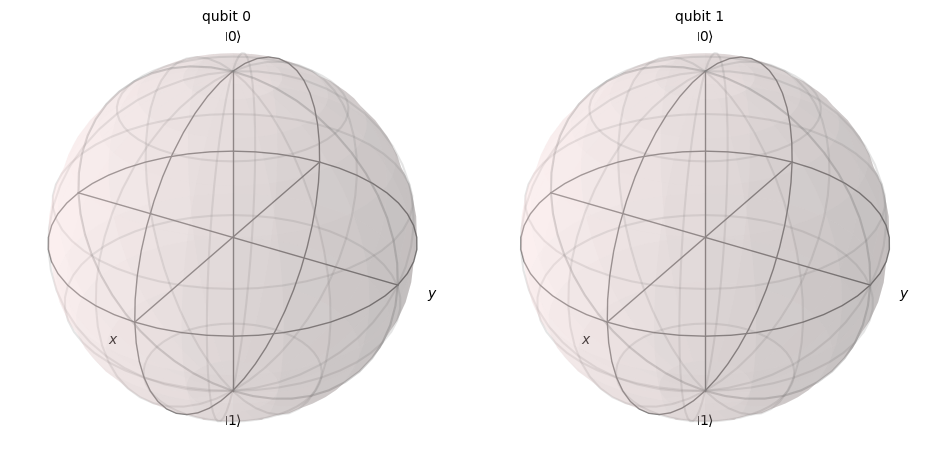

In [ ]:
plot_bloch_multivector(psi)

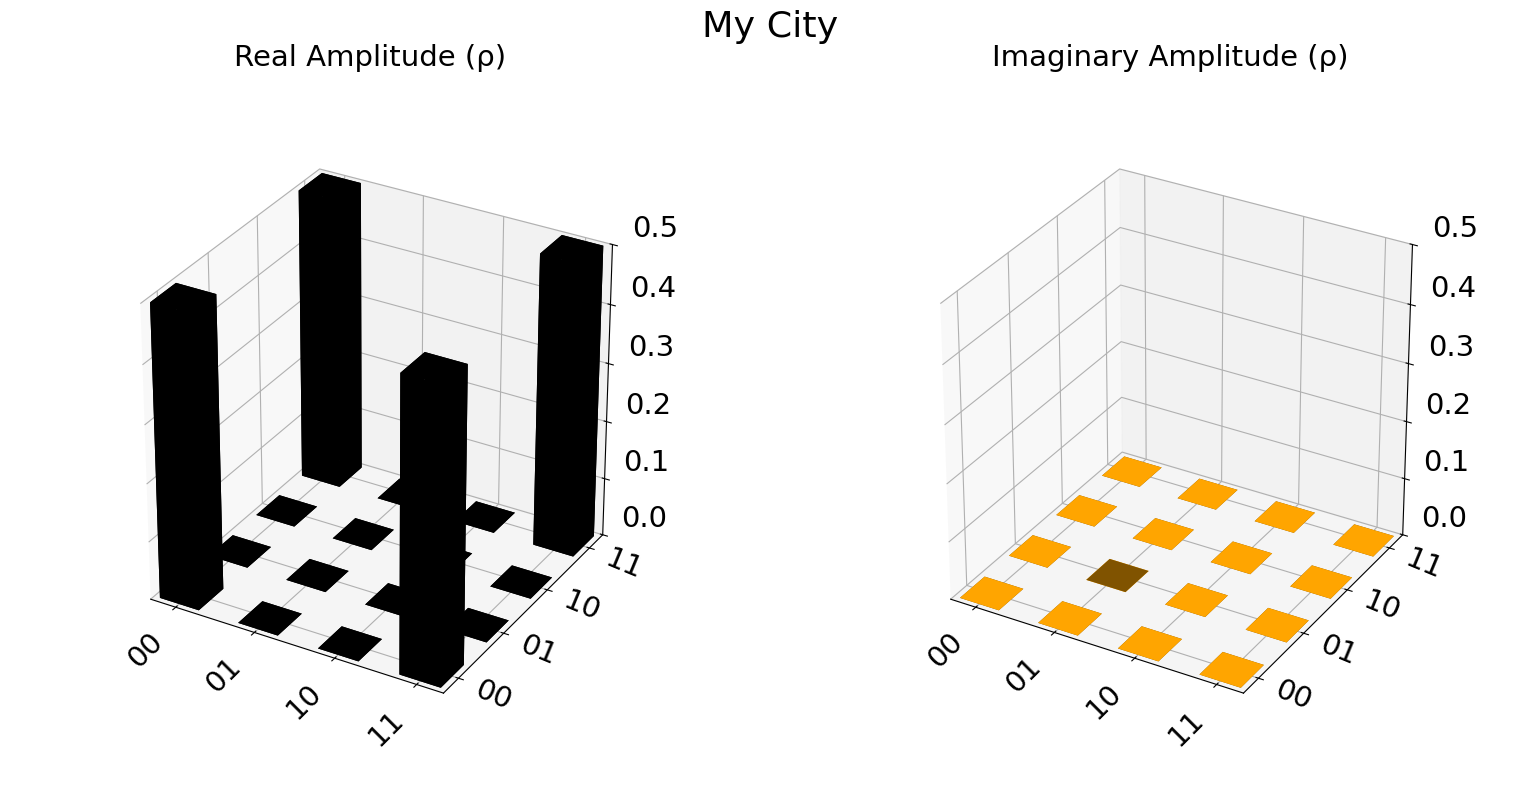

In [ ]:
plot_state_city(psi, title="My City", color=['black', 'orange'])

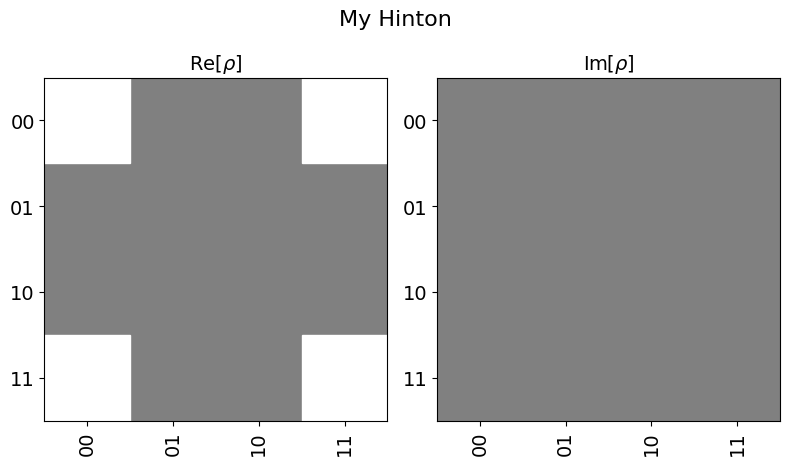

In [ ]:
plot_state_hinton(psi, title="My Hinton")

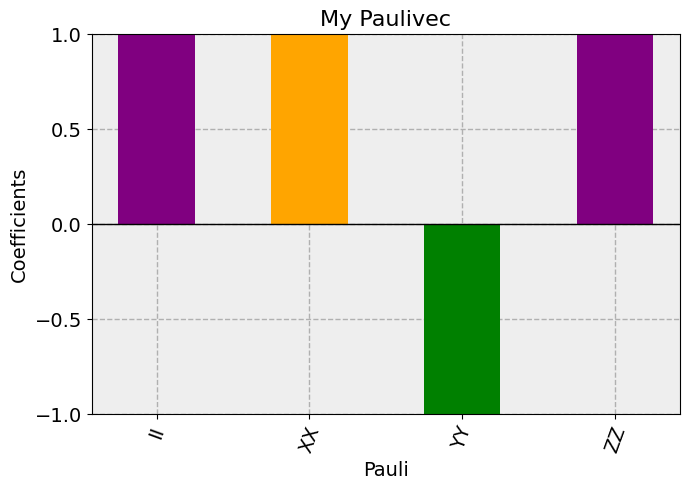

In [ ]:
plot_state_paulivec(psi, title="My Paulivec", color=['purple', 'orange', 'green'])

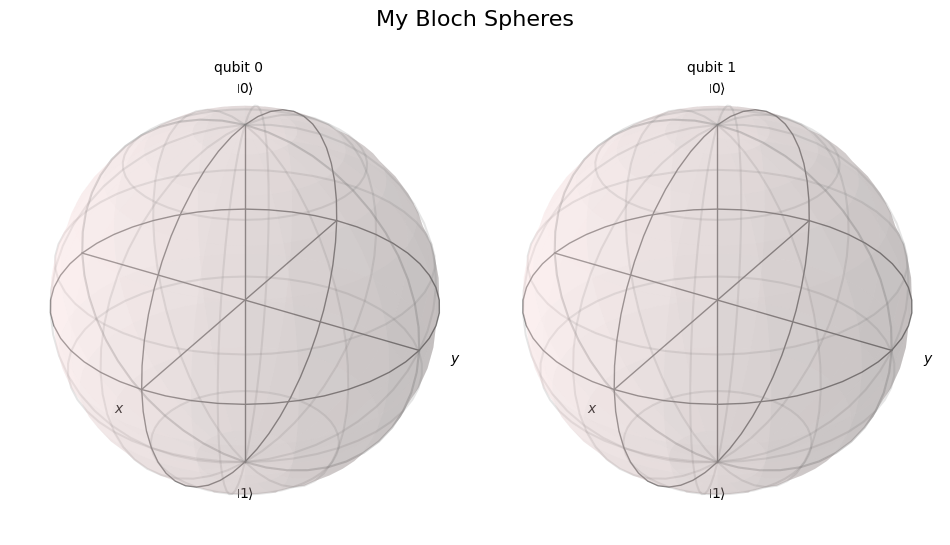

In [ ]:
plot_bloch_multivector(psi, title="My Bloch Spheres")

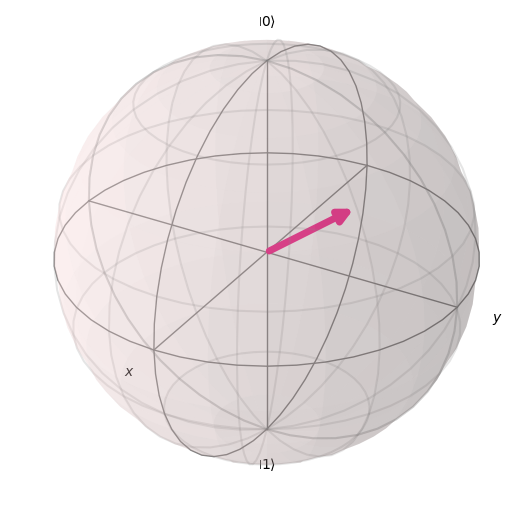

In [ ]:
# plotting block vector
from qiskit.visualization import plot_bloch_vector

plot_bloch_vector([1, 1, 1])